# Statistical Analysis using Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('libraries loaded!')

libraries loaded!


In [2]:
df = pd.read_csv('world_population.csv')
print('dataset loaded')
print('shape:', df.shape)
df.head()

dataset loaded
shape: (234, 17)


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [3]:
print('column names:')
print(df.columns.tolist())
print()
print('missing values:')
print(df.isnull().sum())

column names:
['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']

missing values:
Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64


In [4]:
df = df.dropna()
df = df.drop_duplicates()
print('data cleaned!')
print('shape after cleaning:', df.shape)

data cleaned!
shape after cleaning: (234, 17)


In [5]:
print('basic statistical summary:')
df.describe()

basic statistical summary:


,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.000000,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,234.000000,234.000000,234.000000
mean,117.500000,3.407441e+07,3.350107e+07,3.172996e+07,2.984524e+07,2.626947e+07,2.271022e+07,1.898462e+07,1.578691e+07,5.814494e+05,452.127044,1.009577,0.427051
std,67.694165,1.367664e+08,1.355899e+08,1.304050e+08,1.242185e+08,1.116982e+08,9.783217e+07,8.178519e+07,6.779509e+07,1.761841e+06,2066.121904,0.013385,1.714977
min,1.000000,5.100000e+02,5.200000e+02,5.640000e+02,5.960000e+02,6.510000e+02,7.000000e+02,7.330000e+02,7.520000e+02,1.000000e+00,0.026100,0.912000,0.000000
25%,59.250000,4.197385e+05,4.152845e+05,4.046760e+05,3.931490e+05,3.272420e+05,2.641158e+05,2.296142e+05,1.559970e+05,2.650000e+03,38.417875,1.001775,0.010000
50%,117.500000,5.559944e+06,5.493074e+06,5.307400e+06,4.942770e+06,4.292907e+06,3.825410e+06,3.141146e+06,2.604830e+06,8.119950e+04,95.346750,1.007900,0.070000
75%,175.750000,2.247650e+07,2.144798e+07,1.973085e+07,1.915957e+07,1.576230e+07,1.186923e+07,9.826054e+06,8.817329e+06,4.304258e+05,238.933250,1.016950,0.280000
max,234.000000,1.425887e+09,1.424930e+09,1.393715e+09,1.348191e+09,1.264099e+09,1.153704e+09,9.823725e+08,8.225344e+08,1.709824e+07,23172.266700,1.069100,17.880000


In [6]:
pop_col = '2022 Population'

print('Statistical measures for 2022 Population:')
print()
print('Mean:', round(df[pop_col].mean(), 2))
print('Median:', round(df[pop_col].median(), 2))
print('Mode:', df[pop_col].mode()[0])
print('Standard Deviation:', round(df[pop_col].std(), 2))
print('Variance:', round(df[pop_col].var(), 2))
print('Skewness:', round(df[pop_col].skew(), 2))
print('Kurtosis:', round(df[pop_col].kurtosis(), 2))

Statistical measures for 2022 Population:

Mean: 34074414.71
Median: 5559944.5
Mode: 510
Standard Deviation: 136766424.8
Variance: 1.870505495387683e+16
Skewness: 9.15
Kurtosis: 90.46


In [7]:
print('top 10 most populated countries in 2022:')
top10 = df.nlargest(10, '2022 Population')[['Country/Territory', '2022 Population']]
print(top10)

top 10 most populated countries in 2022:
    Country/Territory  2022 Population
41              China       1425887337
92              India       1417173173
221     United States        338289857
93          Indonesia        275501339
156          Pakistan        235824862
149           Nigeria        218541212
27             Brazil        215313498
16         Bangladesh        171186372
171            Russia        144713314
131            Mexico        127504125


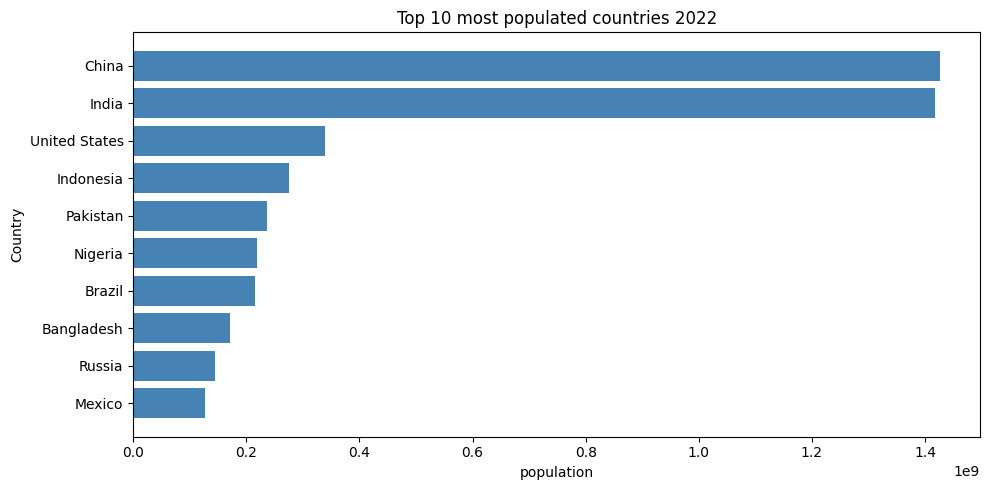

In [8]:
plt.figure(figsize=(10, 5))
plt.barh(top10['Country/Territory'], top10['2022 Population'], color='steelblue')
plt.title('Top 10 most populated countries 2022')
plt.xlabel('population')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

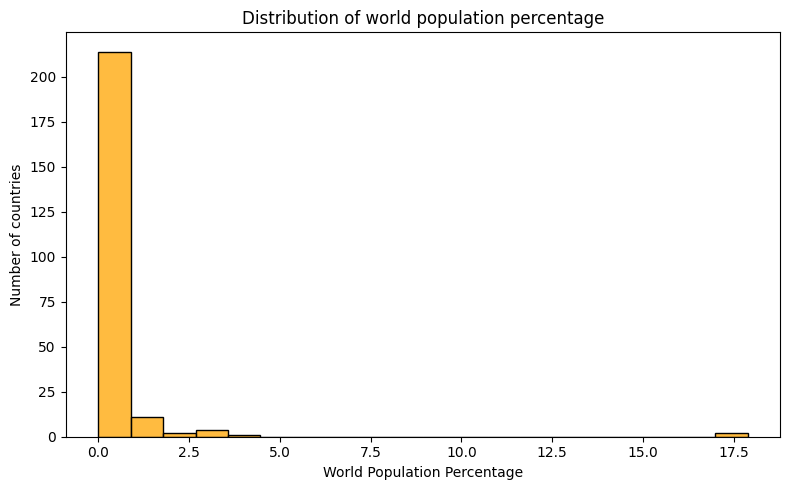

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['World Population Percentage'], bins=20, color='orange')
plt.title('Distribution of world population percentage')
plt.xlabel('World Population Percentage')
plt.ylabel('Number of countries')
plt.tight_layout()
plt.show()

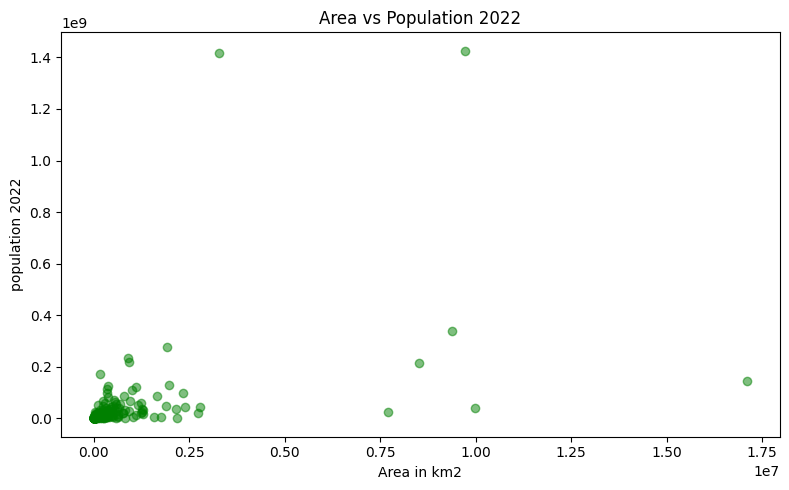

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Area (km²)'], df['2022 Population'], color='green', alpha=0.5)
plt.title('Area vs Population 2022')
plt.xlabel('Area in km2')
plt.ylabel('population 2022')
plt.tight_layout()
plt.show()

In [11]:
corr_coef, p_value = stats.pearsonr(df['Area (km²)'], df['2022 Population'])
print('Pearson Correlation between Area and Population:')
print('Correlation coefficient:', round(corr_coef, 4))
print('P value:', round(p_value, 4))
print()
if p_value < 0.05:
    print('Result: There is a significant correlation between area and population')
else:
    print('Result: There is no significant correlation between area and population')

Pearson Correlation between Area and Population:
Correlation coefficient: 0.4534
P value: 0.0

Result: There is a significant correlation between area and population


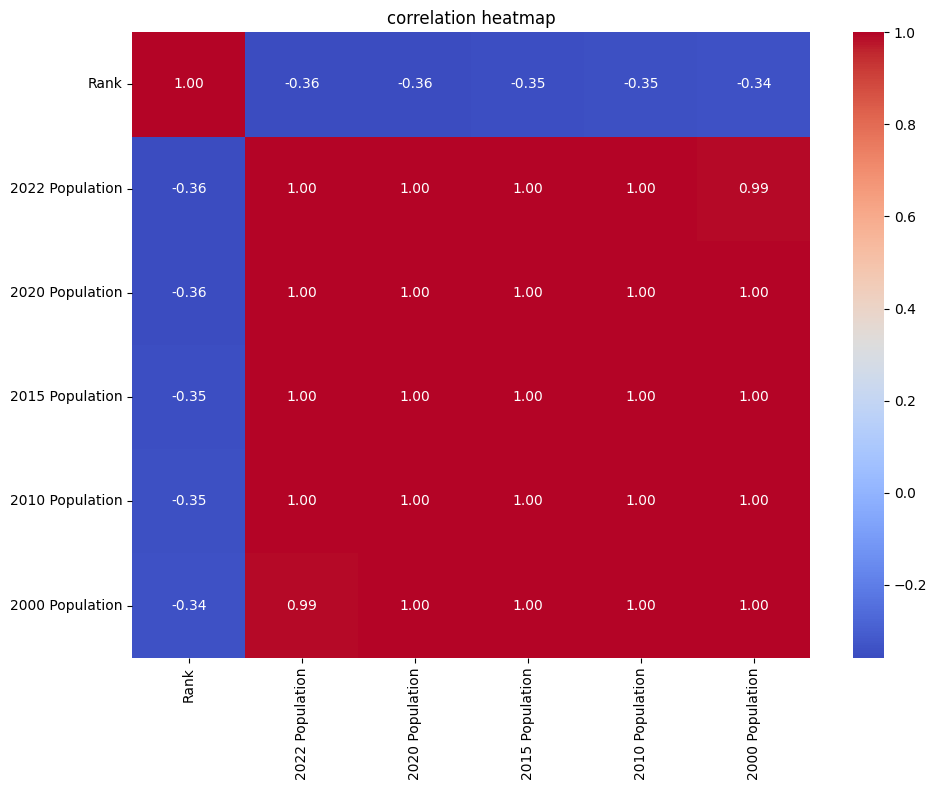

In [12]:
plt.figure(figsize=(10, 8))
num_cols = df.select_dtypes(include=np.number).columns[:6]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation heatmap')
plt.tight_layout()
plt.show()

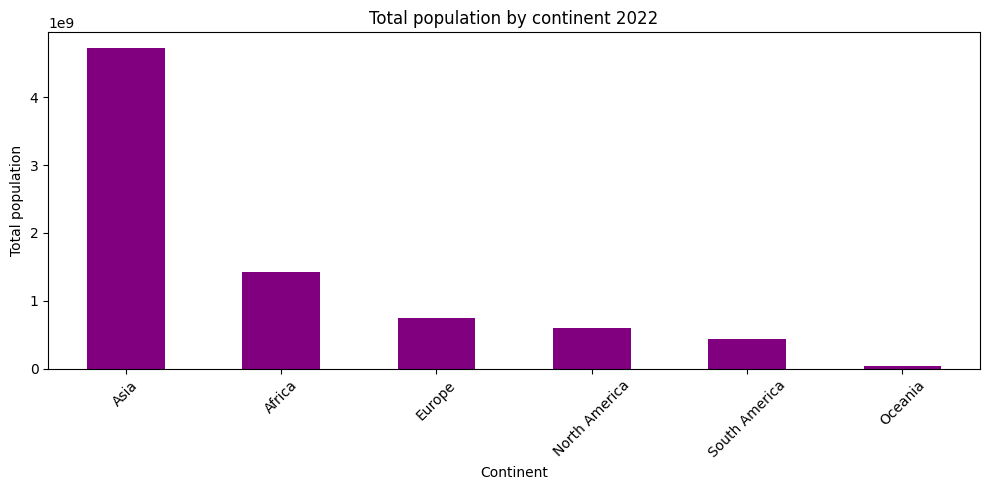

In [13]:
continent_pop = df.groupby('Continent')['2022 Population'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
continent_pop.plot(kind='bar', color='purple')
plt.title('Total population by continent 2022')
plt.xlabel('Continent')
plt.ylabel('Total population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
print('key findings from statistical analysis:')
print()
print('1. China and India are the most populated countries in 2022')
print('2. Asia has the highest total population among all continents')
print('3. Population distribution is highly skewed')
print('4. Area and population have moderate positive correlation')
print('5. Most countries have less than 1 percent of world population')
print('6. Standard deviation is very high showing large variation between countries')
print('7. Median population is much lower than mean due to outliers')
print('8. Africa has the highest number of countries but lower total population than Asia')

key findings from statistical analysis:

1. China and India are the most populated countries in 2022
2. Asia has the highest total population among all continents
3. Population distribution is highly skewed
4. Area and population have moderate positive correlation
5. Most countries have less than 1 percent of world population
6. Standard deviation is very high showing large variation between countries
7. Median population is much lower than mean due to outliers
8. Africa has the highest number of countries but lower total population than Asia


## Summary

In this project i performed statistical analysis on world population dataset using python.

- loaded and cleaned the world population dataset
- calculated mean, median, mode, standard deviation and variance
- identified top 10 most populated countries in 2022
- used pearson correlation to find relationship between area and population
- created bar charts, scatter plots and heatmaps for visualization
- found that asia has the highest total population
- population distribution is highly skewed due to large countries like china and india
- statistical analysis helps understand global population patterns clearly